In [8]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Vector Math & Kinematic Utilities for Awkward Arrays
# =========================================================
def to_cartesian(pt, eta, phi, m=0.0):
    """Converts pt, eta, phi, mass to px, py, pz, E"""
    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    E = np.sqrt(px**2 + py**2 + pz**2 + m**2)
    return px, py, pz, E

def calc_mass(px, py, pz, E):
    """Calculates invariant mass from 4-momentum components"""
    mass2 = E**2 - px**2 - py**2 - pz**2
    return np.sqrt(np.maximum(0, mass2))

def calc_dphi(phi1, phi2):
    """Calculates delta phi bounded between -pi and pi"""
    dphi = (phi1 - phi2 + np.pi) % (2 * np.pi) - np.pi
    return dphi

def calc_dR(eta1, phi1, eta2, phi2):
    """Calculates delta R"""
    deta = eta1 - eta2
    dphi = calc_dphi(phi1, phi2)
    return np.sqrt(deta**2 + dphi**2)


# =========================================================
# Manual MET Calculation Functions
# =========================================================
def calculate_met_towers_muons(tower_et, tower_phi, mu_pt, mu_phi):
    """
    Calculates MET using all raw Calorimeter Towers plus all reconstructed Muons.
    This mimics the robust Base card MET behavior.
    """
    # 1. Calorimeter Towers px, py
    tower_px = tower_et * np.cos(tower_phi)
    tower_py = tower_et * np.sin(tower_phi)
    sum_tower_px = ak.sum(tower_px, axis=1)
    sum_tower_py = ak.sum(tower_py, axis=1)

    # 2. Muons px, py
    muon_px = mu_pt * np.cos(mu_phi)
    muon_py = mu_pt * np.sin(mu_phi)
    sum_muon_px = ak.sum(muon_px, axis=1)
    sum_muon_py = ak.sum(muon_py, axis=1)

    # 3. Negative vector sum
    met_px = -(sum_tower_px + sum_muon_px)
    met_py = -(sum_tower_py + sum_muon_py)
    
    met_pt = np.sqrt(met_px**2 + met_py**2)
    met_phi = np.arctan2(met_py, met_px)
    
    return met_pt, met_phi, met_px, met_py


def calculate_met_objects(jet_pt, jet_phi, ele_pt, ele_phi, mu_pt, mu_phi):
    """
    Calculates "Type-1" MET using only reconstructed high-pT objects 
    (Jets, Electrons, Muons). Ignores unclustered soft energy.
    """
    # Calculate px, py for all objects
    jet_px = jet_pt * np.cos(jet_phi)
    jet_py = jet_pt * np.sin(jet_phi)
    
    ele_px = ele_pt * np.cos(ele_phi)
    ele_py = ele_pt * np.sin(ele_phi)
    
    mu_px = mu_pt * np.cos(mu_phi)
    mu_py = mu_pt * np.sin(mu_phi)

    # Sum all px and py
    sum_px = ak.sum(jet_px, axis=1) + ak.sum(ele_px, axis=1) + ak.sum(mu_px, axis=1)
    sum_py = ak.sum(jet_py, axis=1) + ak.sum(ele_py, axis=1) + ak.sum(mu_py, axis=1)

    # Negative vector sum
    met_px = -sum_px
    met_py = -sum_py
    
    met_pt = np.sqrt(met_px**2 + met_py**2)
    met_phi = np.arctan2(met_py, met_px)
    
    return met_pt, met_phi, met_px, met_py


# =========================================================
# Extraction Function
# =========================================================
def extract_all_observables(tree, met_method="towers"):
    """
    Extracts all observables. 
    met_method options: "towers" (manual), "objects" (manual), or "default" (from Delphes tree)
    """
    # --- Leptons ---
    ele_pt  = tree["Electron.PT"].array()
    ele_eta = tree["Electron.Eta"].array()
    ele_phi = tree["Electron.Phi"].array()
    
    mu_pt   = tree["Muon.PT"].array()
    mu_eta  = tree["Muon.Eta"].array()
    mu_phi  = tree["Muon.Phi"].array()
    
    # Merge & Sort Leptons by pT
    lep_pt  = ak.concatenate([ele_pt, mu_pt], axis=1)
    lep_eta = ak.concatenate([ele_eta, mu_eta], axis=1)
    lep_phi = ak.concatenate([ele_phi, mu_phi], axis=1)
    
    lep_sort = ak.argsort(lep_pt, ascending=False)
    lep_pt   = lep_pt[lep_sort]
    lep_eta  = lep_eta[lep_sort]
    lep_phi  = lep_phi[lep_sort]

    # Mask for valid leptons (pT > 25, |eta| < 2.5)
    valid_leps = (lep_pt > 25.0) & (np.abs(lep_eta) < 2.5)
    has_one_lep = ak.sum(valid_leps, axis=1) == 1
    
    lead_lep_pt  = ak.fill_none(ak.firsts(lep_pt[valid_leps]), 0)
    lead_lep_eta = ak.fill_none(ak.firsts(lep_eta[valid_leps]), 0)
    lead_lep_phi = ak.fill_none(ak.firsts(lep_phi[valid_leps]), 0)
    
    lep_px, lep_py, lep_pz, lep_E = to_cartesian(lead_lep_pt, lead_lep_eta, lead_lep_phi, m=0.0)

    # --- Extract Raw Jets for Object-based MET before masking ---
    raw_jet_pt   = tree["Jet.PT"].array()
    raw_jet_phi  = tree["Jet.Phi"].array()

    # --- MET Calculation ---
    if met_method == "towers":
        try:
            tower_et  = tree["Tower.ET"].array()
            tower_phi = tree["Tower.Phi"].array()
            met_pt, met_phi, met_px, met_py = calculate_met_towers_muons(
                tower_et, tower_phi, mu_pt, mu_phi
            )
        except ValueError:
            print("Warning: 'Tower' branch missing! Falling back to 'default' Delphes MET.")
            met_pt  = tree["MissingET.MET"].array()[:, 0]
            met_phi = tree["MissingET.Phi"].array()[:, 0]
            met_px, met_py, _, _ = to_cartesian(met_pt, 0.0, met_phi, m=0.0)
            
    elif met_method == "objects":
        met_pt, met_phi, met_px, met_py = calculate_met_objects(
            raw_jet_pt, raw_jet_phi, ele_pt, ele_phi, mu_pt, mu_phi
        )
        
    else:  # Default to what Delphes calculated natively
        met_pt  = tree["MissingET.MET"].array()[:, 0]
        met_phi = tree["MissingET.Phi"].array()[:, 0]
        met_px, met_py, _, _ = to_cartesian(met_pt, 0.0, met_phi, m=0.0)

    # Transverse Mass (mTW)
    dphi_lep_met = calc_dphi(lead_lep_phi, met_phi)
    mtw = np.sqrt(2 * lead_lep_pt * met_pt * (1 - np.cos(dphi_lep_met)))

    # --- Small-R Jets ---
    jet_pt   = tree["Jet.PT"].array()
    jet_eta  = tree["Jet.Eta"].array()
    jet_phi  = tree["Jet.Phi"].array()
    jet_mass = tree["Jet.Mass"].array()
    jet_btag = tree["Jet.BTag"].array()

    jet_mask = (jet_pt > 25.0) & (np.abs(jet_eta) < 2.5)
    jets_pt  = jet_pt[jet_mask]
    jets_eta = jet_eta[jet_mask]
    jets_phi = jet_phi[jet_mask]
    jets_m   = jet_mass[jet_mask]
    jets_b   = jet_btag[jet_mask]
    
    n_jets  = ak.num(jets_pt)
    is_b    = (jets_b > 0)
    n_bjets = ak.sum(is_b, axis=1)

    # Separate first two b-jets and the remaining light jets
    idx = ak.local_index(jets_pt, axis=1)
    
    # Filter for the indices of only the b-tagged jets
    b_idx = idx[is_b]
    
    first_b = ak.fill_none(ak.firsts(b_idx), -1)
    second_b = ak.fill_none(ak.firsts(b_idx[:, 1:]), -1)
    
    b_mask = (idx == first_b) | (idx == second_b)
    light_mask = ~b_mask
    
    # --- Large-R (Fat) Jets ---
    fj_pt   = tree["FatJet.PT"].array()
    fj_eta  = tree["FatJet.Eta"].array()
    fj_phi  = tree["FatJet.Phi"].array()
    fj_mass = tree["FatJet.Mass"].array()
    fj_tau2 = tree["FatJet.Tau[5]"].array()[:, :, 1]
    fj_tau3 = tree["FatJet.Tau[5]"].array()[:, :, 2]
    fj_tau32 = np.where(fj_tau2 > 0, fj_tau3 / fj_tau2, 999.0)

    # FatJet Top Tagging Criteria
    fj_mask = (fj_pt > 300.0) & (fj_pt < 1500.0) & (np.abs(fj_eta) < 2.0) & (fj_mass > 100.0) & (fj_tau32 < 0.75)
    n_fjs = ak.sum(fj_mask, axis=1)

    # ==========================================
    # RESOLVED TOPOLOGY SELECTION & RECONSTRUCTION
    # ==========================================
    resolved_mask = has_one_lep & (n_jets >= 4) & (n_bjets >= 2)
    res_out = {}
    print(sum(resolved_mask), f"events passed resolved selection (using MET method: {met_method})")
    
    if ak.sum(resolved_mask) > 0:
        r_lep_px, r_lep_py, r_lep_pz, r_lep_E = lep_px[resolved_mask], lep_py[resolved_mask], lep_pz[resolved_mask], lep_E[resolved_mask]
        r_met_pt, r_met_x, r_met_y = met_pt[resolved_mask], met_px[resolved_mask], met_py[resolved_mask]
        
        # 1. Reconstruct Neutrino Pz
        mW = 80.399
        k = (mW**2) / 2.0 + (r_lep_px * r_met_x + r_lep_py * r_met_y)
        a = r_lep_E**2 - r_lep_pz**2
        b = -2.0 * k * r_lep_pz
        c = (r_lep_E**2) * (r_met_pt**2) - k**2
        disc = b**2 - 4.0 * a * c
        
        # Quadratic roots
        pz_nu = np.where(
            disc < 0, 
            -b / (2.0 * a), 
            np.where( np.abs((-b - np.sqrt(np.maximum(0, disc))) / (2.0 * a)) < np.abs((-b + np.sqrt(np.maximum(0, disc))) / (2.0 * a)),
                      (-b - np.sqrt(np.maximum(0, disc))) / (2.0 * a),
                      (-b + np.sqrt(np.maximum(0, disc))) / (2.0 * a) )
        )
        nu_E = np.sqrt(r_met_x**2 + r_met_y**2 + pz_nu**2)
        
        # W leptonic 4-vector
        wl_px, wl_py, wl_pz, wl_E = r_lep_px + r_met_x, r_lep_py + r_met_y, r_lep_pz + pz_nu, r_lep_E + nu_E
        
        # 2. Assign b-jets to leptonic and hadronic tops
        r_b_pt  = jets_pt[b_mask][resolved_mask]
        r_b_eta = jets_eta[b_mask][resolved_mask]
        r_b_phi = jets_phi[b_mask][resolved_mask]
        r_b_m   = jets_m[b_mask][resolved_mask]
        
        b1_px, b1_py, b1_pz, b1_E = to_cartesian(r_b_pt[:, 0], r_b_eta[:, 0], r_b_phi[:, 0], r_b_m[:, 0])
        b2_px, b2_py, b2_pz, b2_E = to_cartesian(r_b_pt[:, 1], r_b_eta[:, 1], r_b_phi[:, 1], r_b_m[:, 1])
        
        dr1 = calc_dR(r_b_eta[:, 0], r_b_phi[:, 0], lead_lep_eta[resolved_mask], lead_lep_phi[resolved_mask])
        dr2 = calc_dR(r_b_eta[:, 1], r_b_phi[:, 1], lead_lep_eta[resolved_mask], lead_lep_phi[resolved_mask])
        
        b_lep_px = np.where(dr1 < dr2, b1_px, b2_px)
        b_lep_py = np.where(dr1 < dr2, b1_py, b2_py)
        b_lep_pz = np.where(dr1 < dr2, b1_pz, b2_pz)
        b_lep_E  = np.where(dr1 < dr2, b1_E,  b2_E)
        
        b_had_px = np.where(dr1 < dr2, b2_px, b1_px)
        b_had_py = np.where(dr1 < dr2, b2_py, b1_py)
        b_had_pz = np.where(dr1 < dr2, b2_pz, b1_pz)
        b_had_E  = np.where(dr1 < dr2, b2_E,  b1_E)
        
        # 3. Find W hadronic from Light Jets
        r_lj_pt  = jets_pt[light_mask][resolved_mask]
        r_lj_eta = jets_eta[light_mask][resolved_mask]
        r_lj_phi = jets_phi[light_mask][resolved_mask]
        r_lj_m   = jets_m[light_mask][resolved_mask]
        
        lj_px, lj_py, lj_pz, lj_E = to_cartesian(r_lj_pt, r_lj_eta, r_lj_phi, r_lj_m)
        
        # Combinatorics for W_had (minimize |M_jj - 80.4|)
        pairs_px = ak.combinations(lj_px, 2)
        pairs_py = ak.combinations(lj_py, 2)
        pairs_pz = ak.combinations(lj_pz, 2)
        pairs_E  = ak.combinations(lj_E, 2)
        
        p1_px, p2_px = ak.unzip(pairs_px)
        p1_py, p2_py = ak.unzip(pairs_py)
        p1_pz, p2_pz = ak.unzip(pairs_pz)
        p1_E, p2_E   = ak.unzip(pairs_E)
        
        pair_m = calc_mass(p1_px+p2_px, p1_py+p2_py, p1_pz+p2_pz, p1_E+p2_E)
        best_pair_idx = ak.argmin(np.abs(pair_m - mW), axis=1)
        
        # Select best pair 4-vectors
        idx = ak.local_index(pair_m, axis=1) == best_pair_idx
        wh_px = ak.flatten( (p1_px+p2_px)[idx] )
        wh_py = ak.flatten( (p1_py+p2_py)[idx] )
        wh_pz = ak.flatten( (p1_pz+p2_pz)[idx] )
        wh_E  = ak.flatten( (p1_E+p2_E)[idx] )
        
        # 4. Form Tops
        tlep_px, tlep_py, tlep_pz, tlep_E = wl_px + b_lep_px, wl_py + b_lep_py, wl_pz + b_lep_pz, wl_E + b_lep_E
        thad_px, thad_py, thad_pz, thad_E = wh_px + b_had_px, wh_py + b_had_py, wh_pz + b_had_pz, wh_E + b_had_E
        tt_px, tt_py, tt_pz, tt_E = tlep_px + thad_px, tlep_py + thad_py, tlep_pz + thad_pz, tlep_E + thad_E
        
        # Save Resolved Observables
        res_out['n_bjets'] = np.clip(n_bjets[resolved_mask], None, 4)
        res_out['lead_bjet_eta'] = r_b_eta[:, 0]
        res_out['n_jets'] = np.clip(n_jets[resolved_mask], None, 8)
        res_out['jet_pt'] = ak.flatten(jets_pt[resolved_mask])
        res_out['lep_pt'] = r_lep_px**2 + r_lep_py**2 # Placeholder for pt conversion below
        res_out['lep_pt'] = np.sqrt(res_out['lep_pt'])
        res_out['met'] = r_met_pt
        res_out['m_t_lep'] = calc_mass(tlep_px, tlep_py, tlep_pz, tlep_E)
        res_out['m_t_had'] = calc_mass(thad_px, thad_py, thad_pz, thad_E)
        res_out['m_tt']    = calc_mass(tt_px, tt_py, tt_pz, tt_E)

    # ==========================================
    # BOOSTED TOPOLOGY SELECTION
    # ==========================================
    # Initial Preselection
    bst_presel = has_one_lep & (met_pt > 20) & ((met_pt + mtw) > 60) & (n_fjs >= 1) & (n_bjets >= 1)
    
    bst_out = {}
    if ak.sum(bst_presel) > 0:
        # Get properties for the events passing preselection
        p_fj_pt  = fj_pt[fj_mask][bst_presel]
        p_fj_phi = fj_phi[fj_mask][bst_presel]
        p_fj_eta = fj_eta[fj_mask][bst_presel]
        p_lep_phi = lead_lep_phi[bst_presel]
        p_lep_eta = lead_lep_eta[bst_presel]
        
        # Get first top-tagged fatjet
        lead_fatjet_phi = p_fj_phi[:, 0]
        lead_fatjet_eta = p_fj_eta[:, 0]
        
        dphi_fatjet = np.abs(calc_dphi(p_lep_phi, lead_fatjet_phi))
        pass_dphi = dphi_fatjet > 1.0
        
        # B-tag matching Logic from Rivet
        p_j_eta  = jets_eta[bst_presel]
        p_j_phi  = jets_phi[bst_presel]
        p_j_btag = jets_b[bst_presel]
        
        dr_jet_fj = calc_dR(p_j_eta, p_j_phi, lead_fatjet_eta, lead_fatjet_phi)
        dr_jet_lep = calc_dR(p_j_eta, p_j_phi, p_lep_eta, p_lep_phi)
        
        # Condition 1: b-jet far from fatjet but close to lepton
        lep_btag_cond = (dr_jet_fj > 1.5) & (dr_jet_lep < 2.0) & (p_j_btag > 0)
        has_lep_btag = ak.sum(lep_btag_cond, axis=1) > 0
        
        # Condition 2: b-jet inside the fatjet
        had_btag_cond = (dr_jet_fj < 1.0) & (p_j_btag > 0)
        has_had_btag = ak.sum(had_btag_cond, axis=1) > 0
        
        # Final boosted mask
        final_bst = pass_dphi & (has_lep_btag | has_had_btag)
        
        # Save Boosted Observables for those passing final cuts
        bst_out['n_fatjets'] = np.clip(n_fjs[bst_presel][final_bst], None, 3)
        bst_out['lead_fj_pt'] = p_fj_pt[:, 0][final_bst]
        bst_out['lep_pt']  = lead_lep_pt[bst_presel][final_bst]
        bst_out['lep_eta'] = lead_lep_eta[bst_presel][final_bst]
        bst_out['met']     = met_pt[bst_presel][final_bst]
        bst_out['mtw']     = mtw[bst_presel][final_bst]

    n_generated = len(tree["Event"].array())
    return res_out, bst_out, n_generated

In [9]:
# ---------------------------------------------------------
# Run Extraction
# ---------------------------------------------------------
print("Processing Base Card...")
base_res, base_bst, base_ngen = extract_all_observables(uproot.open("run_01/ttbar_base_R4.root")["Delphes"], met_method="default")

print("Processing New Run 2 Card...")
run2_res, run2_bst, run2_ngen = extract_all_observables(uproot.open("run_01/ttbar_Run2_JES_TRK.root")["Delphes"], met_method="default")

Processing Base Card...


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


21726 events passed resolved selection (using MET method: default)
Processing New Run 2 Card...
21567 events passed resolved selection (using MET method: default)


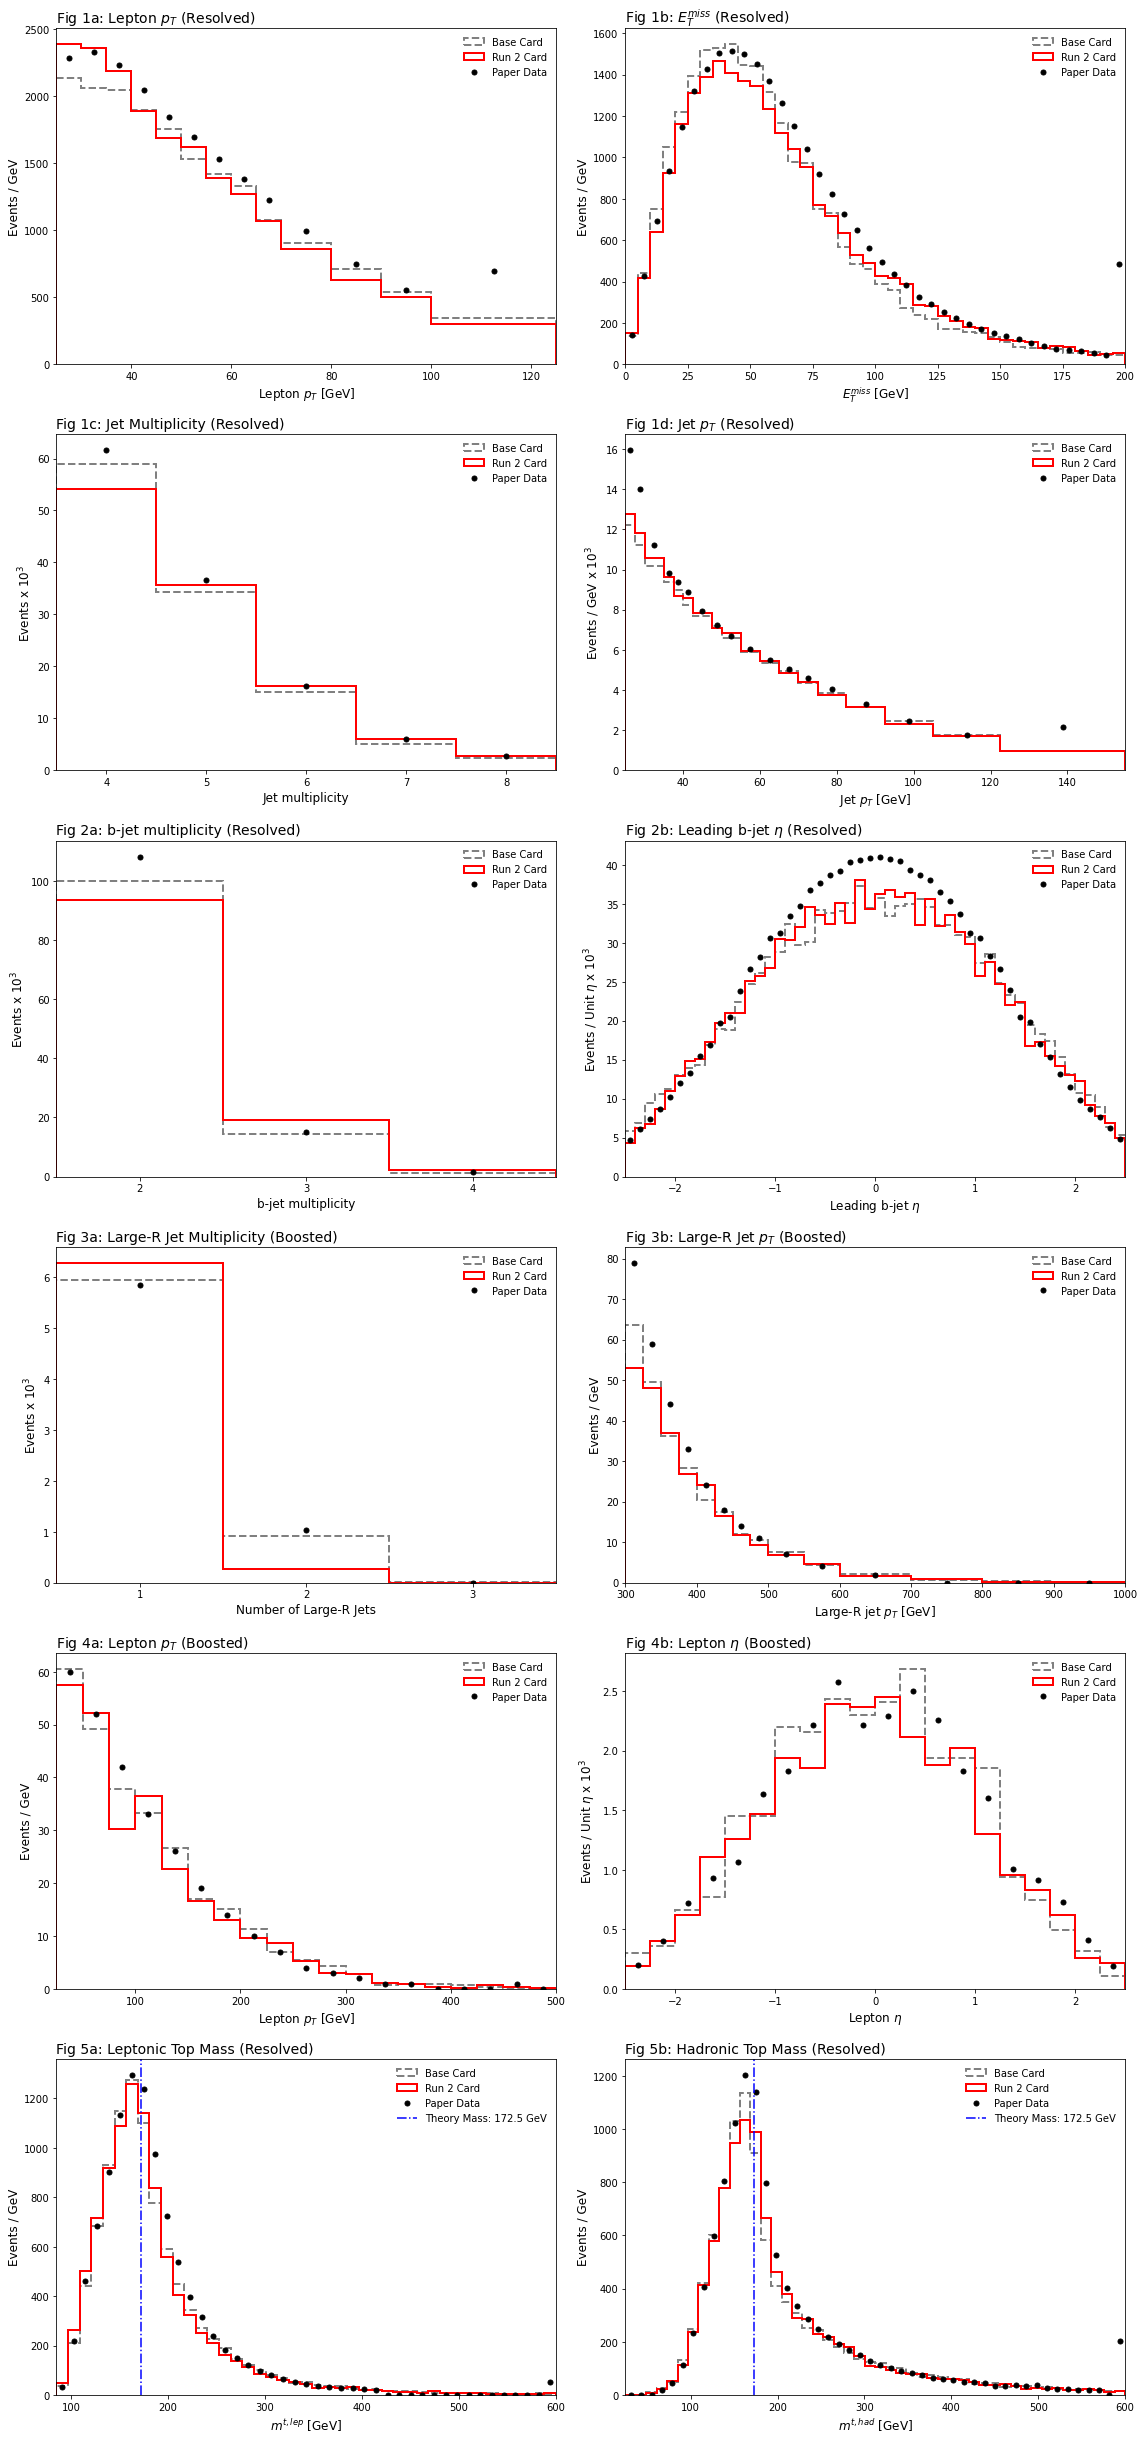

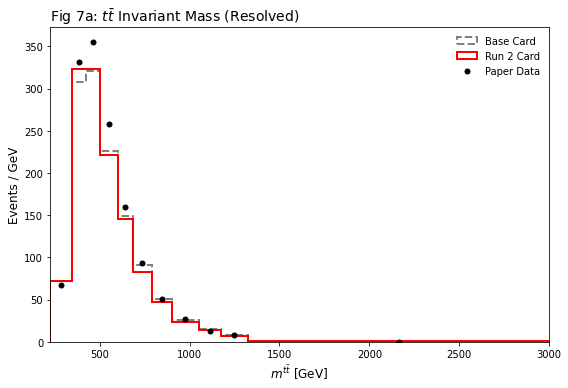

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Weights & Normalization
# ---------------------------------------------------------
lumi_pb = 3200.0
xsec_pb = 504.8
# xsec_pb = 831.76
k_factor = 1.65
# k_factor = 1.0

# Weight PER EVENT
base_w_val = (lumi_pb * xsec_pb * k_factor) / base_ngen
run2_w_val = (lumi_pb * xsec_pb * k_factor) / run2_ngen

# ---------------------------------------------------------
# CSV Extraction Function for Paper Data
# ---------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# CSV Extraction Function for Paper Data
# ---------------------------------------------------------
def read_csv_data(filename):
    """
    Reads the digitized paper data from the CSV.
    Uses column indices:
      3: Left bin edge (x0)
      4: Right bin edge (x1)
      5: Event counts (n_events)
    """
    try:
        df = pd.read_csv(filename)
        
        # Drop rows where the interval edges or event counts are NaN
        df = df.dropna(subset=[df.columns[3], df.columns[4], df.columns[5]])
        
        left_edges = df.iloc[:, 3].values.astype(float)
        right_edges = df.iloc[:, 4].values.astype(float)
        events = df.iloc[:, 5].values.astype(float)
        
        # Create a single array for all bin edges
        bins = np.append(left_edges, right_edges[-1])
        
        return bins, events
    except Exception as e:
        print(f"Warning: Could not load {filename}. Exception: {e}")
        return None, None

# ---------------------------------------------------------
# Updated Plotting Function (Variable Bin Width Support)
# ---------------------------------------------------------
def plot_hist(ax, base_data, run2_data, default_bins, range_val, title, xlabel, ylabel, 
              xticks=None, theory_mass=None, scale_weight=1, csv_file=None):
    
    # 1. Determine Initial Binning
    bins = default_bins
    if isinstance(bins, int):
        bins = np.linspace(range_val[0], range_val[1], bins + 1)
    elif isinstance(bins, list):
        bins = np.array(bins)
        
    csv_events = None
    
    # 2. Load CSV Data if available and Override Bins
    if csv_file is not None:
        csv_bins, csv_events = read_csv_data(csv_file)
        if csv_bins is not None:
            bins = csv_bins # Force MC to use exactly the data binning from the paper
            
    bin_widths = np.diff(bins)
    
    # 3. Compute MC histograms using the matched bins
    base_counts, _ = np.histogram(base_data, bins=bins)
    run2_counts, _ = np.histogram(run2_data, bins=bins)
    
    # Scale counts by the total weight, divide by exact bin width and scale_weight
    base_plot_vals = (base_counts * base_w_val) / bin_widths / scale_weight
    run2_plot_vals = (run2_counts * run2_w_val) / bin_widths / scale_weight
    
    # Plot MC (using the precomputed bin values)
    # We pass bins[:-1] as the "data" to match the shape of the weights
    ax.hist(bins[:-1], bins=bins, weights=base_plot_vals, histtype='step', 
            color='gray', linestyle='dashed', linewidth=2, label='Base Card')
    ax.hist(bins[:-1], bins=bins, weights=run2_plot_vals, histtype='step', 
            color='red', linewidth=2, label='Run 2 Card')
    
    # 4. Plot the CSV Paper Data
    if csv_events is not None:
        # Scale the paper data to match the y-axis (e.g., dividing by 1000)
        csv_events_scaled = csv_events / scale_weight
        bin_centers = (bins[:-1] + bins[1:]) / 2
        ax.plot(bin_centers, csv_events_scaled, 'ko', markersize=5, label='Paper Data')
    
    # 5. Add Theoretical reference line
    if theory_mass is not None:
        ax.axvline(x=theory_mass, color='blue', linestyle='-.', linewidth=1.5, 
                   label=f'Theory Mass: {theory_mass} GeV')

    # Formatting
    ax.set_title(title, fontsize=14, loc='left')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlim(bins[0], bins[-1]) # Restrict x-axis to the actual binned region
    
    if xticks: 
        ax.set_xticks(xticks)
    ax.legend(frameon=False)
# ---------------------------------------------------------
# Master Plotting Execution
# ---------------------------------------------------------
fig, axs = plt.subplots(6, 2, figsize=(16, 34))

# --- FIGURE 1: Resolved Kinematics ---
plot_hist(axs[0,0], base_res['lep_pt'], run2_res['lep_pt'], default_bins=25, range_val=(0, 125), 
          title="Fig 1a: Lepton $p_T$ (Resolved)", xlabel="Lepton $p_T$ [GeV]", ylabel="Events / GeV",
          csv_file="SPP ttbar - Lepton pT (res).csv")

plot_hist(axs[0,1], base_res['met'], run2_res['met'], default_bins=40, range_val=(0, 200), 
          title="Fig 1b: $E_T^{miss}$ (Resolved)", xlabel="$E_T^{miss}$ [GeV]", ylabel="Events / GeV",
          csv_file="SPP ttbar - MET (res).csv")

plot_hist(axs[1,0], base_res['n_jets'], run2_res['n_jets'], default_bins=[3.5, 4.5, 5.5, 6.5, 7.5, 8.5], range_val=(3.5, 8.5), 
          title="Fig 1c: Jet Multiplicity (Resolved)", xlabel="Jet multiplicity", ylabel="Events x $10^3$", xticks=[4,5,6,7,8], scale_weight=1000,
          csv_file="SPP ttbar - Jet Multiplicity (res).csv")

plot_hist(axs[1,1], base_res['jet_pt'], run2_res['jet_pt'], default_bins=30, range_val=(0, 150), 
          title="Fig 1d: Jet $p_T$ (Resolved)", xlabel="Jet $p_T$ [GeV]", ylabel="Events / GeV x $10^3$", scale_weight=1000,
          csv_file="SPP ttbar - Jet pT (res).csv")

# --- FIGURE 2: Resolved b-jets ---
plot_hist(axs[2,0], base_res['n_bjets'], run2_res['n_bjets'], default_bins=[1.5, 2.5, 3.5, 4.5], range_val=(1.5, 4.5), 
          title="Fig 2a: b-jet multiplicity (Resolved)", xlabel="b-jet multiplicity", ylabel="Events x $10^3$", xticks=[2,3,4], scale_weight=1000,
          csv_file="SPP ttbar - b-jet multiplicity.csv")

plot_hist(axs[2,1], base_res['lead_bjet_eta'], run2_res['lead_bjet_eta'], default_bins=25, range_val=(-2.5, 2.5), 
          title="Fig 2b: Leading b-jet $\eta$ (Resolved)", xlabel="Leading b-jet $\eta$", ylabel="Events / Unit $\eta$ x $10^3$", scale_weight=1000,
          csv_file="SPP ttbar - Leading b-jet eta.csv")

# --- FIGURE 3: Boosted Large-R Jets ---
plot_hist(axs[3,0], base_bst['n_fatjets'], run2_bst['n_fatjets'], default_bins=[0.5, 1.5, 2.5, 3.5], range_val=(0.5, 3.5), 
          title="Fig 3a: Large-R Jet Multiplicity (Boosted)", xlabel="Number of Large-R Jets", ylabel="Events x $10^3$", xticks=[1,2,3], scale_weight=1000,
          csv_file="SPP ttbar - N-LargeRjets.csv")

plot_hist(axs[3,1], base_bst['lead_fj_pt'], run2_bst['lead_fj_pt'], default_bins=35, range_val=(300, 1000), 
          title="Fig 3b: Large-R Jet $p_T$ (Boosted)", xlabel="Large-R jet $p_T$ [GeV]", ylabel="Events / GeV",
          csv_file="SPP ttbar - pt-LargeRjets.csv")

# --- FIGURE 4: Boosted Kinematics ---
plot_hist(axs[4,0], base_bst['lep_pt'], run2_bst['lep_pt'], default_bins=25, range_val=(0, 500), 
          title="Fig 4a: Lepton $p_T$ (Boosted)", xlabel="Lepton $p_T$ [GeV]", ylabel="Events / GeV",
          csv_file="SPP ttbar - Lepton pT (bost).csv")

plot_hist(axs[4,1], base_bst['lep_eta'], run2_bst['lep_eta'], default_bins=25, range_val=(-2.5, 2.5), 
          title="Fig 4b: Lepton $\eta$ (Boosted)", xlabel="Lepton $\eta$", ylabel="Events / Unit $\eta$ x $10^3$", scale_weight=1000,
          csv_file="SPP ttbar - Lepton eta(bost).csv")

# --- FIGURE 5: Resolved Reconstruction Masses ---
plot_hist(axs[5,0], base_res['m_t_lep'], run2_res['m_t_lep'], default_bins=30, range_val=(0, 600), 
          title="Fig 5a: Leptonic Top Mass (Resolved)", xlabel="$m^{t,lep}$ [GeV]", ylabel="Events / GeV", theory_mass=172.5,
          csv_file="SPP ttbar - m_t_lep.csv")

plot_hist(axs[5,1], base_res['m_t_had'], run2_res['m_t_had'], default_bins=30, range_val=(0, 600), 
          title="Fig 5b: Hadronic Top Mass (Resolved)", xlabel="$m^{t,had}$ [GeV]", ylabel="Events / GeV", theory_mass=172.5,
          csv_file="SPP ttbar - m_t_had.csv")

# plot_hist(axs[6,0], base_bst['met'], run2_bst['met'], default_bins=50, range_val=(0, 400), 
#           title="Fig 4c: Missing $E_T$ (Boosted)", xlabel="$E_T^{miss}$ [GeV]", ylabel="Events / GeV",
#           csv_file=None) # Assume no specific MET(boosted) CSV

# plot_hist(axs[6,1], base_bst['mtw'], run2_bst['mtw'], default_bins=50, range_val=(0, 200), 
#           title="Fig 4d: Transverse Mass (Boosted)", xlabel="$m_T^W$ [GeV]", ylabel="Events / GeV", theory_mass=80.4)

plt.tight_layout()
plt.show()

# --- FIGURE 7: m_tt (Separate Figure Block) ---
fig_tt, ax_tt = plt.subplots(1, 1, figsize=(8, 5.5))
plot_hist(ax_tt, base_res['m_tt'], run2_res['m_tt'], default_bins=30, range_val=(0, 3000), 
          title="Fig 7a: $t\\bar{t}$ Invariant Mass (Resolved)", xlabel="$m^{t\\bar{t}}$ [GeV]", ylabel="Events / GeV",
          csv_file="SPP ttbar - m_tt.csv")

plt.tight_layout()
plt.show()

### JES

Loading raw MC data from: run_01/ttbar_Run2.root
Loading Paper Data from: SPP ttbar - m_t_had.csv
Testing A = 1...
Testing A = 2...
Testing A = 3...
Testing A = 4...
Testing A = 5...


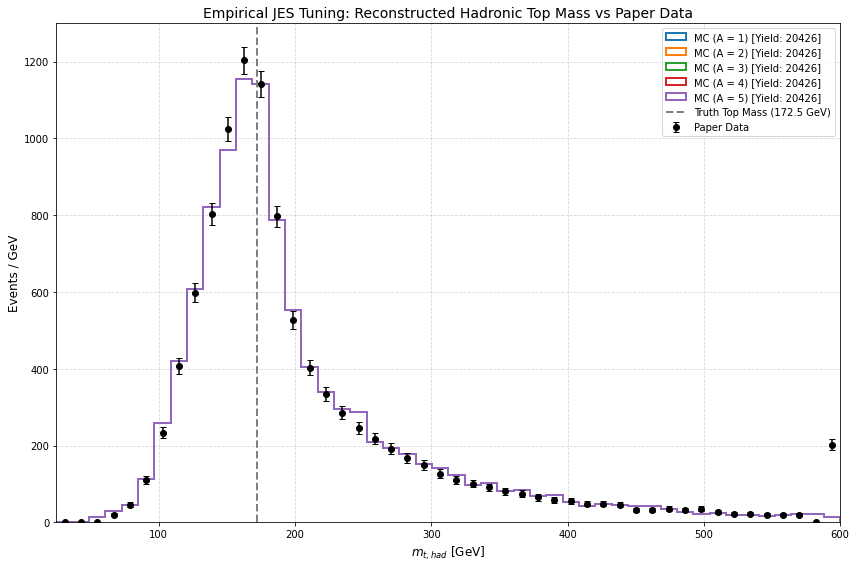

In [11]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Ensure your utility functions (to_cartesian, calc_mass, etc.) and read_csv_data are loaded here ---

def run_jes_scan_with_csv(raw_mc_filepath, csv_filepath, test_A_values=[3.0, 4.0, 4.5, 5.0, 5.5, 6.0]):
    """
    Scans JES parameters on raw MC and overlays the binned real data from a CSV.
    Uses the exact binning defined in the CSV.
    """
    print(f"Loading raw MC data from: {raw_mc_filepath}")
    tree = uproot.open(raw_mc_filepath)["Delphes"]
    
    # 1. Load the Paper Data from CSV
    print(f"Loading Paper Data from: {csv_filepath}")
    csv_bins, csv_events = read_csv_data(csv_filepath)
    if csv_bins is None:
        print("CRITICAL ERROR: Could not load CSV data. Aborting scan.")
        return
    
    # The paper data will dictate the binning for the MC
    bin_widths = np.diff(csv_bins)
    bin_centers = (csv_bins[:-1] + csv_bins[1:]) / 2
    
    # 2. Set up Plot
    plt.figure(figsize=(12, 8))
    
    # Plot the Paper Data as black dots
    plt.errorbar(bin_centers, csv_events, yerr=np.sqrt(csv_events), fmt='ko', 
                 markersize=6, capsize=3, elinewidth=1.5, label='Paper Data', zorder=10)

    # 3. Extract Leptons & Raw Jets
    ele_pt, ele_eta, ele_phi = tree["Electron.PT"].array(), tree["Electron.Eta"].array(), tree["Electron.Phi"].array()
    mu_pt, mu_eta, mu_phi = tree["Muon.PT"].array(), tree["Muon.Eta"].array(), tree["Muon.Phi"].array()
    
    lep_pt = ak.concatenate([ele_pt, mu_pt], axis=1)
    lep_eta = ak.concatenate([ele_eta, mu_eta], axis=1)
    lep_phi = ak.concatenate([ele_phi, mu_phi], axis=1)
    
    lep_sort = ak.argsort(lep_pt, ascending=False)
    lep_pt, lep_eta, lep_phi = lep_pt[lep_sort], lep_eta[lep_sort], lep_phi[lep_sort]

    valid_leps = (lep_pt > 25.0) & (np.abs(lep_eta) < 2.5)
    has_one_lep = ak.sum(valid_leps, axis=1) == 1
    lead_lep_eta = ak.fill_none(ak.firsts(lep_eta[valid_leps]), 0)
    lead_lep_phi = ak.fill_none(ak.firsts(lep_phi[valid_leps]), 0)

    raw_jet_pt = tree["Jet.PT"].array()
    raw_jet_eta = tree["Jet.Eta"].array()
    raw_jet_phi = tree["Jet.Phi"].array()
    raw_jet_mass = tree["Jet.Mass"].array()
    raw_jet_btag = tree["Jet.BTag"].array()

    # Need MC weights to scale the simulation properly against the paper data
    lumi_pb = 3200.0
    xsec_pb = 504.8
    k_factor = 1.65
    n_generated = len(lep_pt)
    
    # 4. Scan the A Parameter
    for A in test_A_values:
        mc_weight = (lumi_pb * xsec_pb * k_factor* 1.15) / n_generated

        print(f"Testing A = {A}...")
        # print(len(raw_jet_pt), "events in raw jet collection before cuts.")
        # Scale = sqrt( (A - 0.2*|eta|)^2 / raw_pt + 1.0 )
        scale_factor = np.sqrt( (3.5 - 0.2*np.abs(raw_jet_eta))**2 / raw_jet_pt + 1)
        calib_pt = raw_jet_pt * scale_factor
        calib_mass = raw_jet_mass * scale_factor
        
        # Offline cuts on scaled jets
        jet_mask = (calib_pt > 25) & (np.abs(raw_jet_eta) < 2.5)
        jets_pt, jets_eta, jets_phi, jets_m, jets_b = calib_pt[jet_mask], raw_jet_eta[jet_mask], raw_jet_phi[jet_mask], calib_mass[jet_mask], raw_jet_btag[jet_mask]
        
        n_jets = ak.num(jets_pt)
        n_bjets = ak.sum(jets_b > 0, axis=1)
        resolved_mask = has_one_lep & (n_jets >= 4) & (n_bjets >= 2)
        
        if ak.sum(resolved_mask) == 0:
            continue
            
        r_j_pt, r_j_eta, r_j_phi, r_j_m, r_j_b = jets_pt[resolved_mask], jets_eta[resolved_mask], jets_phi[resolved_mask], jets_m[resolved_mask], jets_b[resolved_mask]
        r_lep_eta, r_lep_phi = lead_lep_eta[resolved_mask], lead_lep_phi[resolved_mask]
        
        is_b = (r_j_b > 0)
        idx = ak.local_index(r_j_pt, axis=1)
        b_idx = idx[is_b]
        
        first_b = ak.fill_none(ak.firsts(b_idx), -1)
        second_b = ak.fill_none(ak.firsts(b_idx[:, 1:]), -1)
        b_mask = (idx == first_b) | (idx == second_b)
        light_mask = ~b_mask
        
        # Hadronic W Reconstruction
        r_lj_pt, r_lj_eta, r_lj_phi, r_lj_m = r_j_pt[light_mask], r_j_eta[light_mask], r_j_phi[light_mask], r_j_m[light_mask]
        lj_px, lj_py, lj_pz, lj_E = to_cartesian(r_lj_pt, r_lj_eta, r_lj_phi, r_lj_m)
        
        pairs_px = ak.combinations(lj_px, 2); p1_px, p2_px = ak.unzip(pairs_px)
        pairs_py = ak.combinations(lj_py, 2); p1_py, p2_py = ak.unzip(pairs_py)
        pairs_pz = ak.combinations(lj_pz, 2); p1_pz, p2_pz = ak.unzip(pairs_pz)
        pairs_E  = ak.combinations(lj_E, 2);  p1_E, p2_E   = ak.unzip(pairs_E)
        
        pair_m = calc_mass(p1_px+p2_px, p1_py+p2_py, p1_pz+p2_pz, p1_E+p2_E)
        best_pair_idx = ak.argmin(np.abs(pair_m - 80.399), axis=1)
        
        best_idx_mask = ak.local_index(pair_m, axis=1) == best_pair_idx
        wh_px, wh_py = ak.flatten((p1_px+p2_px)[best_idx_mask]), ak.flatten((p1_py+p2_py)[best_idx_mask])
        wh_pz, wh_E  = ak.flatten((p1_pz+p2_pz)[best_idx_mask]), ak.flatten((p1_E+p2_E)[best_idx_mask])
        
        # B-Jet Assignment (Hadronic top gets the b-jet furthest from lepton)
        r_b_pt, r_b_eta, r_b_phi, r_b_m = r_j_pt[b_mask], r_j_eta[b_mask], r_j_phi[b_mask], r_j_m[b_mask]
        b1_px, b1_py, b1_pz, b1_E = to_cartesian(r_b_pt[:, 0], r_b_eta[:, 0], r_b_phi[:, 0], r_b_m[:, 0])
        b2_px, b2_py, b2_pz, b2_E = to_cartesian(r_b_pt[:, 1], r_b_eta[:, 1], r_b_phi[:, 1], r_b_m[:, 1])
        
        dr1 = calc_dR(r_b_eta[:, 0], r_b_phi[:, 0], r_lep_eta, r_lep_phi)
        dr2 = calc_dR(r_b_eta[:, 1], r_b_phi[:, 1], r_lep_eta, r_lep_phi)
        
        b_had_px = np.where(dr1 < dr2, b2_px, b1_px)
        b_had_py = np.where(dr1 < dr2, b2_py, b1_py)
        b_had_pz = np.where(dr1 < dr2, b2_pz, b1_pz)
        b_had_E  = np.where(dr1 < dr2, b2_E,  b1_E)
        
        # Final Hadronic Top Mass
        thad_px, thad_py = wh_px + b_had_px, wh_py + b_had_py
        thad_pz, thad_E  = wh_pz + b_had_pz, wh_E + b_had_E
        m_t_had = ak.to_numpy(calc_mass(thad_px, thad_py, thad_pz, thad_E))
        
        # 5. Plotting the Variation using Paper Binning
        mc_counts, _ = np.histogram(m_t_had, bins=csv_bins)
        
        # Scale the MC counts using the exact logic from your plot_hist function
        mc_plot_vals = (mc_counts * mc_weight) / bin_widths 
        
        # We pass csv_bins[:-1] as the data to map the weights correctly to the bins
        plt.hist(csv_bins[:-1], bins=csv_bins, weights=mc_plot_vals, histtype='step', 
                 linewidth=2.0, label=f'MC (A = {A}) [Yield: {len(m_t_had)}]')

    # 6. Plot Formatting
    plt.axvline(172.5, color='gray', linestyle='dashed', linewidth=2, label='Truth Top Mass (172.5 GeV)')
    plt.title("Empirical JES Tuning: Reconstructed Hadronic Top Mass vs Paper Data", fontsize=14)
    plt.xlabel(r'$m_{t,had}$ [GeV]', fontsize=12)
    plt.ylabel('Events / GeV', fontsize=12)
    plt.xlim(csv_bins[0], csv_bins[-1])
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# =========================================================
# Execution
# =========================================================
if __name__ == "__main__":
    # Remember to point this to the ROOT file generated with ScaleFormula {1.0}
    mc_filepath = "run_01/ttbar_Run2.root" 
    csv_filepath = "SPP ttbar - m_t_had.csv"
    
    # Run the scan to find the optimal 'A' parameter
    run_jes_scan_with_csv(mc_filepath, csv_filepath, test_A_values=[1, 2, 3, 4, 5])

### Beyond Standard Model

In [12]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import io
import re
import os

# # =========================================================
# # Vector Math Utilities
# # =========================================================
# def calc_dphi(phi1, phi2):
#     """Calculates delta phi bounded between -pi and pi"""
#     return (phi1 - phi2 + np.pi) % (2 * np.pi) - np.pi

# def calc_dR(eta1, phi1, eta2, phi2):
#     """Calculates delta R"""
#     return np.sqrt((eta1 - eta2)**2 + calc_dphi(phi1, phi2)**2)


In [13]:
import numba as nb
import numpy as np
import awkward as ak

@nb.njit
def _is_unmatched_compiled(trk_eta, trk_phi, obj_eta, obj_phi, dr_cut2):
    """
    The core JIT-compiled C-speed loop. 
    We pass dr_cut squared to avoid running slow square roots inside the loop.
    """
    n_events = len(trk_eta)
    
    # Pre-calculate the total number of tracks to allocate a flat output array
    total_trks = 0
    for i in range(n_events):
        total_trks += len(trk_eta[i])
        
    result = np.empty(total_trks, dtype=np.bool_)
    idx = 0
    
    for i in range(n_events):
        n_trks = len(trk_eta[i])
        n_objs = len(obj_eta[i])
        
        for j in range(n_trks):
            matched = False
            for k in range(n_objs):
                deta = trk_eta[i][j] - obj_eta[i][k]
                dphi = trk_phi[i][j] - obj_phi[i][k]
                
                # Wrap dPhi to between -pi and pi
                if dphi > np.pi:
                    dphi -= 2 * np.pi
                elif dphi < -np.pi:
                    dphi += 2 * np.pi
                    
                # Calculate dR squared
                dr2 = deta**2 + dphi**2
                
                if dr2 < dr_cut2:
                    matched = True
                    break # Optimization: Stop checking objects once a match is found!
                    
            result[idx] = not matched
            idx += 1
            
    return result

def is_unmatched(trk_eta, trk_phi, obj_eta, obj_phi, dr_cut):
    """
    Python wrapper that handles the Awkward Array formatting.
    """
    # Run the compiled C-speed loop
    flat_mask = _is_unmatched_compiled(trk_eta, trk_phi, obj_eta, obj_phi, dr_cut**2)
    
    # Unflatten the 1D numpy array back into the jagged Awkward Array shape
    return ak.unflatten(flat_mask, ak.num(trk_eta))

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [14]:
import uproot
import awkward as ak
import numpy as np

# =========================================================
# Vector Math Utilities
# =========================================================
def calc_dphi(phi1, phi2):
    """Calculates delta phi bounded between -pi and pi"""
    return (phi1 - phi2 + np.pi) % (2 * np.pi) - np.pi

def calc_dR(eta1, phi1, eta2, phi2):
    """Calculates delta R"""
    return np.sqrt((eta1 - eta2)**2 + calc_dphi(phi1, phi2)**2)

def is_unmatched(eta1, phi1, eta2, phi2, dr_cut):
    """
    Returns a boolean mask for obj1. True if obj1 is NOT matched to ANY obj2 within dr_cut.
    Vectorized for Awkward Arrays using cartesian products.
    """
    # Create combinations of all obj1 with all obj2 per event
    eta1_unf, eta2_unf = ak.unzip(ak.cartesian([eta1, eta2], nested=True))
    phi1_unf, phi2_unf = ak.unzip(ak.cartesian([phi1, phi2], nested=True))
    
    dphi = calc_dphi(phi1_unf, phi2_unf)
    deta = eta1_unf - eta2_unf
    dr = np.sqrt(deta**2 + dphi**2)
    
    # Check if ANY obj2 is within dr_cut for each obj1
    is_matched = ak.any(dr < dr_cut, axis=-1)
    
    # We want tracks that are UNMATCHED, so we invert the mask
    return ~is_matched

# =========================================================
# Event Processing (No Overlap Removal + Track MET)
# =========================================================
def process_signal_file(filepath):
    """Reads a Delphes ROOT file, applies cuts, and returns a dict of selected events."""
    tree = uproot.open(f"{filepath}:Delphes")

    # --- 1. Load All Raw Branches ---
    ele_pt  = tree["Electron.PT"].array()
    ele_eta = tree["Electron.Eta"].array()
    ele_phi = tree["Electron.Phi"].array()
    
    mu_pt   = tree["Muon.PT"].array()
    mu_eta  = tree["Muon.Eta"].array()
    mu_phi  = tree["Muon.Phi"].array()

    raw_jet_pt   = tree["Jet.PT"].array()
    raw_jet_eta  = tree["Jet.Eta"].array()
    raw_jet_phi  = tree["Jet.Phi"].array()

    trk_pt  = tree["Track.PT"].array()
    trk_eta = tree["Track.Eta"].array()
    trk_phi = tree["Track.Phi"].array()

    # ht = ak.sum(raw_jet_pt, axis=-1)

    # --- 2. Define MET Objects (Matching C++ exact thresholds) ---
    # Jets: pT > 30 (No eta cut applied here, per C++)
    sel_jet_mask = raw_jet_pt > 30.0
    sel_jet_pt, sel_jet_eta, sel_jet_phi = raw_jet_pt[sel_jet_mask], raw_jet_eta[sel_jet_mask], raw_jet_phi[sel_jet_mask]

    # Electrons: pT > 7, |eta| < 2.5
    sel_ele_mask = (ele_pt > 7.0) & (np.abs(ele_eta) < 2.5)
    sel_ele_pt, sel_ele_eta, sel_ele_phi = ele_pt[sel_ele_mask], ele_eta[sel_ele_mask], ele_phi[sel_ele_mask]

    # Muons (Only needed for vetoing tracks): pT > 7
    all_mu_mask = mu_pt > 7.0
    all_mu_eta, all_mu_phi = mu_eta[all_mu_mask], mu_phi[all_mu_mask]

    # --- 3. Reconstruct MET (Invisible Muon Logic) ---
    # A. Sum Electrons
    sum_px = ak.sum(sel_ele_pt * np.cos(sel_ele_phi), axis=-1)
    sum_py = ak.sum(sel_ele_pt * np.sin(sel_ele_phi), axis=-1)

    # B. Sum Jets
    sum_px = sum_px + ak.sum(sel_jet_pt * np.cos(sel_jet_phi), axis=-1)
    sum_py = sum_py + ak.sum(sel_jet_pt * np.sin(sel_jet_phi), axis=-1)

    # C. Filter Tracks and Add Soft Term
    # Veto tracks near Electrons (dR < 0.05)
    trk_mask = is_unmatched(trk_eta, trk_phi, sel_ele_eta, sel_ele_phi, 0.05)
    # Veto tracks near Jets (dR < 0.4)
    trk_mask = trk_mask & is_unmatched(trk_eta, trk_phi, sel_jet_eta, sel_jet_phi, 0.4)
    # Veto tracks near Muons (dR < 0.05) -> CRITICAL for Invisible Muons
    trk_mask = trk_mask & is_unmatched(trk_eta, trk_phi, all_mu_eta, all_mu_phi, 0.05)

    # Add remaining (unmatched) tracks
    valid_trk_pt, valid_trk_phi = trk_pt[trk_mask], trk_phi[trk_mask]
    sum_px = sum_px + ak.sum(valid_trk_pt * np.cos(valid_trk_phi), axis=-1)
    sum_py = sum_py + ak.sum(valid_trk_pt * np.sin(valid_trk_phi), axis=-1)

    # Finalize MET calculations
    met_pt = np.sqrt(sum_px**2 + sum_py**2)
    met_phi = np.arctan2(-sum_py, -sum_px)

    # --- 4. SIGNAL REGION CUTS ---
    n_jets = ak.num(sel_jet_pt)
    has_2_jets = n_jets >= 2
    
    lead_jet_pt = ak.fill_none(ak.firsts(sel_jet_pt), 0.0)
    lead_jet_cut = lead_jet_pt > 250.0
    
    met_cut = met_pt > 250.0
    
    central_jets = np.abs(sel_jet_eta) < 2.5
    has_2_central = ak.sum(central_jets, axis=-1) >= 2

    # Final Event Mask
    event_mask = has_2_jets & lead_jet_cut & met_cut & has_2_central

    # --- 5. CALCULATE VARIABLES ---
    # Apply mask to save computation
    pass_j_pt = sel_jet_pt[event_mask]
    pass_j_phi = sel_jet_phi[event_mask]
    pass_met_val = met_pt[event_mask]
    pass_met_phi = met_phi[event_mask]

    ht = ak.sum(pass_j_pt, axis=-1)

    # dPhi calculations
    dphis = np.abs(calc_dphi(pass_j_phi, pass_met_phi))
    min_dphi = ak.min(dphis, axis=-1)
    
    idx_close = ak.argmin(dphis, axis=-1, keepdims=True)
    idx_far = ak.argmax(dphis, axis=-1, keepdims=True)
    
    close_pt, close_phi = ak.flatten(pass_j_pt[idx_close]), ak.flatten(pass_j_phi[idx_close])
    far_pt, far_phi = ak.flatten(pass_j_pt[idx_far]), ak.flatten(pass_j_phi[idx_far])

    vClose_px, vClose_py = close_pt * np.cos(close_phi), close_pt * np.sin(close_phi)
    vFar_px, vFar_py = far_pt * np.cos(far_phi), far_pt * np.sin(far_phi)
    
    vec_sum_mod = np.sqrt((vClose_px + vFar_px)**2 + (vClose_py + vFar_py)**2)
    pt_balance = vec_sum_mod / (close_pt + far_pt)
    delta_phi_j1j2 = np.abs(calc_dphi(close_phi, far_phi))

    return {
        "ht": ht.to_numpy(),
        "met": pass_met_val.to_numpy(),
        "min_dPhi": min_dphi.to_numpy(),
        "pt_balance": pt_balance.to_numpy(),
        "delta_phi_j1j2": delta_phi_j1j2.to_numpy(),
    }

In [15]:
# =========================================================
# Configuration & Global Variables
# =========================================================
LUMI = 139  # fb^-1
N_GEN = 100000
# INPUT_BASE = "/home/aegis/Titan0/madgraph/MG5_aMC_v3_7_0/bin/ttbar_validation/Events/BSM_events"
INPUT_BASE = "/home/aegis/ether/replicate_deepak"
TARGET_MODES = ['1000_6', '1000_8', '2000_4', '2000_6', '3000_2', '3000_4']

# Populate Metadata DataFrame (Copied from your script)
DF_META = pd.DataFrame([
    {"Mass": 1000, "Rinv": 2, "XS": 9551.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 4, "XS": 9540.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 6, "XS": 9552.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 8, "XS": 9554.0, "TheoryUnc": 0.52},
    {"Mass": 2000, "Rinv": 2, "XS": 146.3, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 4, "XS": 146.8, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 6, "XS": 146.1, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 8, "XS": 145.3, "TheoryUnc": 0.53},
    {"Mass": 3000, "Rinv": 2, "XS": 14.24, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 4, "XS": 14.20, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 6, "XS": 14.21, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 8, "XS": 14.26, "TheoryUnc": 0.48},
])

def get_metadata(mode):
    parts = mode.split('_')
    row = DF_META[(DF_META['Mass'] == int(parts[0])) & (DF_META['Rinv'] == int(parts[1]))]
    return row.iloc[0]['XS'], row.iloc[0]['TheoryUnc']

# =========================================================
# Run Data Pipeline
# =========================================================
print("Extracting Data from ROOT files...")
sim_dataframes = {}

for mode in TARGET_MODES:
    mass, rinv = mode.split('_')
    # input_file = f"{INPUT_BASE}/{mass}_{rinv}_events.root"
    input_file = f"{INPUT_BASE}/{mass}_{rinv}_events_markXI.root"
    
    if os.path.exists(input_file):
        print(f">>> Processing m={mass}, r={rinv}...")
        results_dict = process_signal_file(input_file)
        sim_dataframes[mode] = pd.DataFrame(results_dict)
    else:
        print(f"Warning: File {input_file} not found. Skipping.")

Extracting Data from ROOT files...
>>> Processing m=1000, r=6...
>>> Processing m=1000, r=8...
>>> Processing m=2000, r=4...
>>> Processing m=2000, r=6...
>>> Processing m=3000, r=2...
>>> Processing m=3000, r=4...


--- Plotting ht ---


/tmp/ipykernel_280890/509729429.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


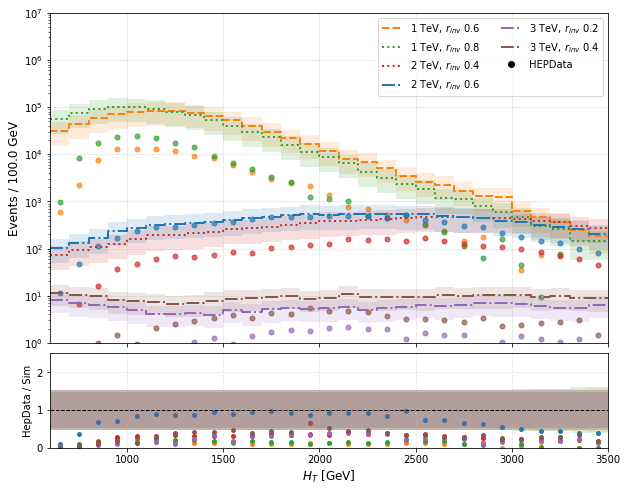

--- Plotting met ---


/tmp/ipykernel_280890/509729429.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


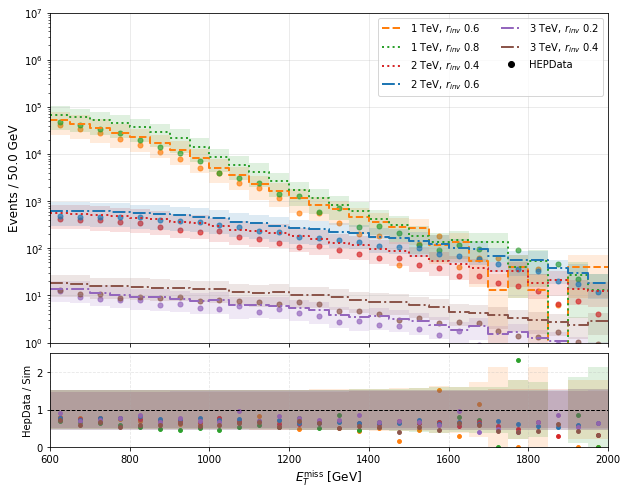

--- Plotting delta_phi_j1j2 ---


/tmp/ipykernel_280890/509729429.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


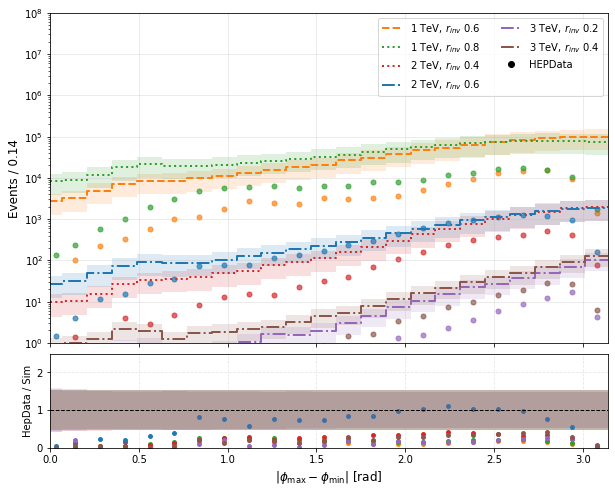

--- Plotting pt_balance ---


/tmp/ipykernel_280890/509729429.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


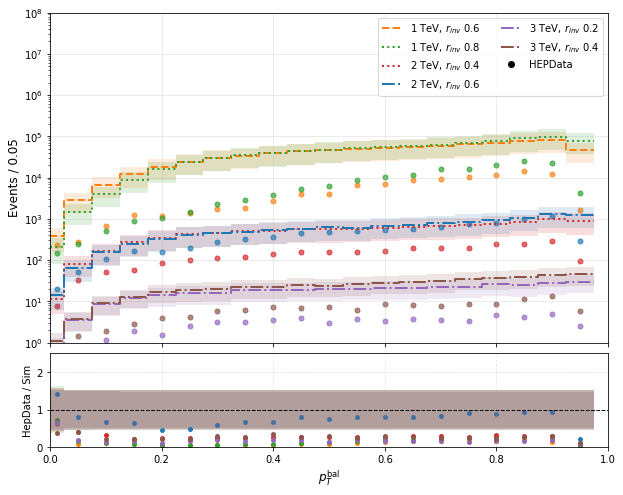

In [16]:
STYLES = {
    '1000_6': ('#ff7f0e', '--'), '1000_8': ('#2ca02c', ':'),
    '2000_4': ('#d62728', ':'),  '2000_6': ('#1f77b4', '-.'),
    '3000_2': ('#9467bd', '-.'), '3000_4': ('#8c564b', '-.')
}

def get_hepdata_dict(filename):
    """Parses HEPData CSV into a dictionary of DataFrames."""
    if not os.path.exists(filename):
        print(f"Error: HEPData file {filename} not found.")
        return {}

    with open(filename, 'r') as f:
        content = f.read()
    
    blocks = content.strip().split('\n\n')
    data_dict = {}
    
    for block in blocks:
        lines = [l for l in block.split('\n') if not l.strip().startswith('#:')]
        if not lines: continue
        
        df = pd.read_csv(io.StringIO('\n'.join(lines)))
        df.columns = [c.strip() for c in df.columns]
        
        sig_col = next((c for c in df.columns if "Signal" in c), None)
        
        if sig_col:
            # Parse "Signal (1 TeV, R$_{inv}$ 0.6)" -> "1000_6"
            match = re.search(r'Signal \((\d+) TeV.* ([0-9\.]+)\)', sig_col)
            if match:
                mass_tev, r_val = match.groups()
                mass_gev = int(mass_tev) * 1000
                key_name = f"{mass_gev}_{r_val.replace('0.', '')[-1]}" 
                data_dict[key_name] = df
            else:
                data_dict[sig_col] = df # Fallback
                
    return data_dict


def compare_simulation_with_hepdata(var_name, hepdata_file, xlabel, norm_val, x_limits, y_limits=(0.01, 1e5)):
    print(f"--- Plotting {var_name} ---")
    hep_data = get_hepdata_dict(hepdata_file)
    if not hep_data: return

    ref_key = list(hep_data.keys())[0]
    ref_df = hep_data[ref_key]
    bin_edges = np.concatenate([ref_df.iloc[:, 1].values, [ref_df.iloc[:, 2].values[-1]]])
    bin_widths = np.diff(bin_edges)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3.5, 1], hspace=0.05)
    ax_main = plt.subplot(gs[0])
    ax_ratio = plt.subplot(gs[1], sharex=ax_main)

    for mode in TARGET_MODES:
        if mode not in sim_dataframes:
            continue
            
        df_sim = sim_dataframes[mode]
        xs_eff, theory_unc_frac = get_metadata(mode)
        
        # Calculate Weights
        norm_factor = (xs_eff * LUMI) / N_GEN
        normalized_weights = np.ones(len(df_sim)) * norm_factor

        # Histogramming
        counts, _ = np.histogram(df_sim[var_name], bins=bin_edges, weights=normalized_weights)
        sum_w2, _ = np.histogram(df_sim[var_name], bins=bin_edges, weights=normalized_weights**2)
        
        scale_factor = (bin_widths / norm_val)
        y_sim = counts / scale_factor
        y_err_stat = np.sqrt(sum_w2) / scale_factor
        y_err_theory = y_sim * theory_unc_frac
        y_err_total = np.sqrt(y_err_stat**2 + y_err_theory**2)

        c, ls = STYLES.get(mode, ('black', '-'))
        mass_tev = int(mode.split('_')[0]) // 1000
        rinv_val = mode.split('_')[1]
        label_txt = f"{mass_tev} TeV, $r_{{inv}}$ 0.{rinv_val}"

        # Plot Main
        y_sim_step = np.append(y_sim, y_sim[-1])
        y_err_step = np.append(y_err_total, y_err_total[-1])
        
        ax_main.step(bin_edges, y_sim_step, where='post', label=label_txt, color=c, linestyle=ls, linewidth=2)
        ax_main.fill_between(bin_edges, y_sim_step - y_err_step, y_sim_step + y_err_step,
                             step='post', color=c, alpha=0.15, edgecolor='none')

        # Plot Ratio
        if mode in hep_data:
            y_ref = hep_data[mode][[col for col in hep_data[mode].columns if "Signal" in col][0]].values
            ax_main.scatter(bin_centers, y_ref, color=c, marker='o', s=25, alpha=0.7)

            valid_bins = y_sim > 0
            ratio = np.zeros_like(y_ref)
            ratio[valid_bins] = y_ref[valid_bins] / y_sim[valid_bins]
            
            ax_ratio.scatter(bin_centers[valid_bins], ratio[valid_bins], color=c, marker='o', s=15)
            
            rel_err = np.zeros_like(y_sim)
            rel_err[valid_bins] = y_err_total[valid_bins] / y_sim[valid_bins]
            rel_err_step = np.append(rel_err, rel_err[-1])
            
            ax_ratio.fill_between(bin_edges, 1.0 - rel_err_step, 1.0 + rel_err_step,
                                  step='post', color=c, alpha=0.15, edgecolor='none')

    # Styling
    ylabel = f"Events / {norm_val} GeV" if norm_val >= 1 else f"Events / {norm_val}"
    ax_main.set_yscale('log')
    ax_main.set_ylabel(ylabel, fontsize=12)
    ax_main.set_xlim(*x_limits)
    ax_main.set_ylim(*y_limits)
    plt.setp(ax_main.get_xticklabels(), visible=False)
    
    handles, labels = ax_main.get_legend_handles_labels()
    handles.append(Line2D([0], [0], marker='o', color='black', linestyle='None', label='HEPData'))
    ax_main.legend(handles=handles, ncol=2, fontsize=10, loc='upper right')
    
    ax_ratio.set_ylabel("HepData / Sim", fontsize=10)
    ax_ratio.set_xlabel(xlabel, fontsize=12)
    ax_ratio.set_xlim(*x_limits)
    ax_ratio.set_ylim(0.0, 2.5)
    ax_ratio.axhline(1.0, color='black', linestyle='--', linewidth=1)
    
    ax_ratio.grid(True, which="both", ls="--", alpha=0.3)
    ax_main.grid(True, which="major", ls="-", alpha=0.3)

    plt.tight_layout()
    os.makedirs("plots", exist_ok=True)
    plt.savefig(f"plots/comparison_{var_name}.pdf")
    plt.show()

# Execute your plots natively!
compare_simulation_with_hepdata('ht', "HEPData-HT.csv", r"$H_T$ [GeV]", 100.0, (600, 3500), (1, 1e7))
compare_simulation_with_hepdata('met', "HEPData-MET.csv", r"$E^{\text{miss}}_T$ [GeV]", 50.0, (600, 2000), (1, 1e7))
compare_simulation_with_hepdata('delta_phi_j1j2', "HEPData-phi.csv", r"$|\phi_{\text{max}} - \phi_{\text{min}}|$ [rad]", 0.14, (0, np.pi), (1, 1e8))
compare_simulation_with_hepdata('pt_balance', "HEPData-pT.csv", r"$p^{\text{bal}}_T$", 0.05, (0, 1), (1, 1e8))